# Edward Moswane Assignment 13: Generative AI Essentials

##  Introduction to Generative AI

Generative AI is a type of AI that can be used for many applications, create text,chatbots, images, code, markerting, translation, education and other content. It is used for chatbots, education, writing, and content creation. In this assignment, the LSTM model was used to generate story text. Assignment 13 will demonstrate, AI-assisted story generation using the trained LSTM model.

In [ ]:
# Import signficant libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import requests

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Dataset Preparation:

In [ ]:
#Chosing to work with Project Gutenberg (http://www.gutenberg.org/)
# Download a public-domain text from Project Gutenberg

url = "https://www.gutenberg.org/files/11/11-0.txt"

response = requests.get(url)
text = response.text

print("Dataset downloaded successfully!")
print("Number of characters:", len(text))
print("\nFirst 1000 characters:\n")
print(text[:1000])

Dataset downloaded successfully!
Number of characters: 144696

First 1000 characters:

*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a b

Text cleaning

In [ ]:
# Cleaning the text to make it consistent
text = text.lower()

# Removing unnecessary whitespace
text = " ".join(text.split())

print("Cleaned text length:", len(text))
print("\nSample of cleaned text:\n")
print(text[:1000])

Cleaned text length: 143221

Sample of cleaned text:

*** start of the project gutenberg ebook 11 *** [illustration] alice’s adventures in wonderland by lewis carroll the millennium fulcrum edition 3.0 contents chapter i. down the rabbit-hole chapter ii. the pool of tears chapter iii. a caucus-race and a long tale chapter iv. the rabbit sends in a little bill chapter v. advice from a caterpillar chapter vi. pig and pepper chapter vii. a mad tea-party chapter viii. the queen’s croquet-ground chapter ix. the mock turtle’s story chapter x. the lobster quadrille chapter xi. who stole the tarts? chapter xii. alice’s evidence chapter i. down the rabbit-hole alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pictures or conversations in it, “and what is the use of a book,” thought alice “without pictures or conversations?” so she was considering in her own min

Tokenize the text

In [ ]:
# Tokenizing the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Total unique words:", total_words)

Total unique words: 3067


# Model Implementation and Training
Generate Training Sequences

In [ ]:
# Create fixed-length training sequences to save memory
sequence_length = 20

token_list = tokenizer.texts_to_sequences([text])[0]

input_sequences = []

# Creating sequences using a fixed window size
for i in range(sequence_length, len(token_list)):
    sequence = token_list[i-sequence_length:i+1]
    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

# Separating input words and target word
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

In [ ]:
print("Number of training sequences:", len(X))
print("Input shape:", X.shape)
print("Target shape:", y.shape)

Number of training sequences: 27745
Input shape: (27745, 20)
Target shape: (27745,)


Build the Long Short Term Memory Text Generation Model

In [ ]:
# Build the LSTM text-generation model
model = Sequential([Embedding(total_words, 64),LSTM(128),Dropout(0.2),
    Dense(total_words, activation='softmax')])

# Compile the model
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [ ]:
# Training the text-generation model
history = model.fit(X,y,epochs=5,batch_size=128,verbose=1)

print("Model training completed.")

Epoch 1/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.0572 - loss: 6.4219
Epoch 2/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.0587 - loss: 6.0227
Epoch 3/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.0778 - loss: 5.8706
Epoch 4/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.0922 - loss: 5.7156
Epoch 5/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.1014 - loss: 5.5817
Model training completed.


Visualize Training Loss

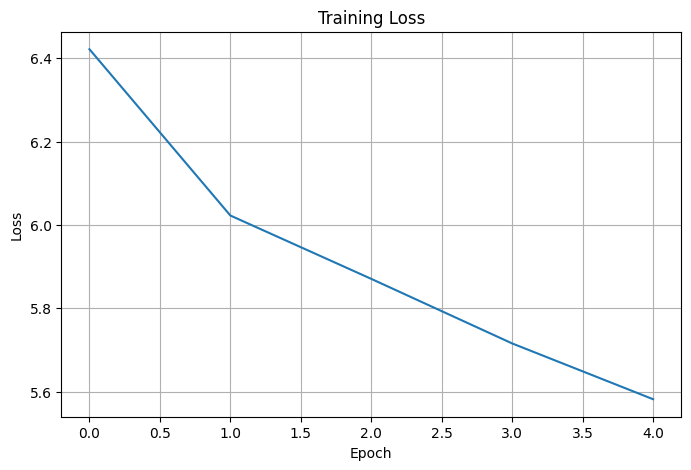

In [ ]:
# Plot training loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'])

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

Generate New Text

In [ ]:
# Generating text using probability-based sampling
def generate_text(seed_text, next_words, model, tokenizer, sequence_length, temperature=0.7):
    generated_text = seed_text

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([generated_text])[0]
        token_list = token_list[-sequence_length:]

        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding='pre')

        predicted = model.predict(token_list, verbose=0)[0]

        # Adjust probabilities using temperature
        predicted = np.log(predicted + 1e-8) / temperature
        probabilities = np.exp(predicted) / np.sum(np.exp(predicted))

        # Randomly select the next word based on probabilities
        predicted_word_index = np.random.choice(len(probabilities),p=probabilities)

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        if output_word == "":
            break

        generated_text += " " + output_word

    return generated_text

In [ ]:
# Generating text with probability-based sampling
seed_text = "alice was beginning"

generated_text = generate_text(seed_text,30,model,tokenizer,sequence_length,temperature=0.7)

print("Seed text:")
print(seed_text)

print("\nGenerated text:")
print(generated_text)

Seed text:
alice was beginning

Generated text:
alice was beginning ” the king she the cat way they and was little make and the king you up to the eyes to can and “where’s and “oh the room and mayn’t


# Application Demonstration
Practical content creation
For the particular demonstration the trained LSTM model receives the seed phrase "once alice entered the garden" and generates additional text based on patterns learned from the Project Gutenberg dataset.

In [ ]:
# Practical content creation demonstration
story_seed = "once alice entered the garden"

story = generate_text(story_seed,40,model,tokenizer,sequence_length,temperature=0.8)

print("AI-Assisted Story Generation")
print("-" * 40)
print(story)

AI-Assisted Story Generation
----------------------------------------
once alice entered the garden who looking ” said the rabbit hours the going of an speed “but on the dormouse so the hatter tree it ” the “ah with the say and was at the thing and said alice than to you round the


# Exploring Generative Pre-trained Transformers (GPTs)

## GPT Architecture and Functionality

GPTs are Artificial inteligence models that learn from large amounts of text in this case our project and generate new text. They use the Transformer architecture to understand the relationship between various words and predict the next words. for example:

If GPT receives “Alice went to the”, it will predicts a likely next word such as “garden”, then further generate more words learned like who looking?

## Transformer Architecture

A Transformer is a type of neural network that helps AI understand the text by looking at various words at the same time. It uses attention to identify which words relate.


## Attention Mechanism

Attention is used by Transformer to identify which words are signficant and related. It searches for the relationships between words and gives more attention to the words that provide useful context. for example:
In “Alice went to the garden because she was curious,” the attention  word will be “she” refering to Alice.

## Tokenization, Probabilities, and Sequence Generation

Tokenization: Will break the text into smaller pieces named tokens.
Transformer: Processes the tokens and understands their relationships.
Attention: Focuses on the most significant words.
Prediction: Calculates probabilities for possible next tokens.
Generation: Selects a token and repeats the process.

## Ethical Considerations and Potential Solutions

Generative AI can be biased and can only produce information based on what it has learned from its training data. It can also provide misinformation or expose sensitive information. Solutions include using diverse data, carefully reviewing AI-generated results, implementing security measures to protect private information, and verifying content before using it.

# Conclusion and Summary of Insights
Generative AI can be useful in many areas, especially education and research, by creating content from learned data. This assignment showed how a simple LSTM model can generate text. Generative AI is becoming more powerful and will continue to have many useful applications in the future.

Colab Link

https://colab.research.google.com/drive/17U4224EZfW0fNCQy46wZ7iVYAi5L4kX0?usp=sharing

GitHUb Link

https://github.com/Edward-Moswane/AI_Assignments/blob/main/Lesson_13_assignment.ipynb